# 01 - 探索的データ分析 (EDA)
**近赤外研究会 スペクトル分析チャレンジ**  
近赤外（NIR）スペクトルから木材の含水率を予測するコンペティション

## このノートブックの目的
- データの基本構造を把握する
- 含水率（ターゲット）の分布を確認する
- NIRスペクトルの形状と樹種ごとの違いを可視化する
- **Train/Testで樹種が完全に異なる**という重要な事実を確認する
- 水の吸収ピーク帯域を確認し、モデル設計の方針を立てる

## 0. ライブラリのインポート

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import japanize_matplotlib  # 日本語フォント対応

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('ライブラリ読み込み完了')

ライブラリ読み込み完了


## 1. データの読み込み・基本確認（read_csv / info・欠損値・describe）

In [2]:
train = pd.read_csv('../data/train_near.csv', encoding='cp932')
test  = pd.read_csv('../data/test_near.csv',  encoding='cp932')
print('データ読み込み完了')

データ読み込み完了


In [3]:
print(train.head())
print(test.head())

   sample number  species number    樹種         含水率  9993.76781  9989.9107  \
0              1               1  イチョウ  216.129032     0.41485    0.41465   
1              2               1  イチョウ  210.752688     0.42049    0.42040   
2              3               1  イチョウ  205.913979     0.41040    0.41045   
3              4               1  イチョウ  201.075269     0.40080    0.40061   
4              5               1  イチョウ  196.236559     0.38792    0.38814   

   9986.05359  9982.19648  9978.33937  9974.48227  ...  4034.53536  \
0     0.41463     0.41476     0.41481     0.41470  ...     1.25104   
1     0.42049     0.42053     0.42038     0.42010  ...     1.21929   
2     0.41047     0.41028     0.41000     0.40989  ...     1.17471   
3     0.40031     0.40008     0.39993     0.39991  ...     1.11271   
4     0.38825     0.38817     0.38798     0.38778  ...     1.05617   

   4030.67826  4026.82115  4022.96404  4019.10693  4015.24982  4011.39271  \
0     1.24925     1.24145     1.23620  

In [4]:
# スペクトル列（波数の数値列）とメタ列を分離
META_COLS  = ['sample number', 'species number', '樹種', '含水率']
SPEC_COLS  = [c for c in train.columns if c not in META_COLS]
WAVENUMS   = np.array([float(c) for c in SPEC_COLS])  # 波数 [cm⁻¹]
WAVELENGTHS = 10_000 / WAVENUMS * 1000                # 波長 [nm] に換算

print(f'Train : {train.shape}  ({len(SPEC_COLS)} スペクトル変数)')
print(f'Test  : {test.shape}')
print(f'波数範囲 : {WAVENUMS.max():.0f} – {WAVENUMS.min():.0f} cm⁻¹')
print(f'波長範囲 : {WAVELENGTHS.min():.0f} – {WAVELENGTHS.max():.0f} nm')

Train : (1322, 1559)  (1555 スペクトル変数)
Test  : (550, 1558)
波数範囲 : 9994 – 4000 cm⁻¹
波長範囲 : 1001 – 2500 nm


In [5]:
train.info()
print(train.isnull().sum().sum())
print(test.isnull().sum().sum())
print(train['含水率'].describe())

<class 'pandas.DataFrame'>
RangeIndex: 1322 entries, 0 to 1321
Columns: 1559 entries, sample number to 3999.82139
dtypes: float64(1556), int64(2), str(1)
memory usage: 15.7 MB
0
0
count    1322.000000
mean       49.937672
std        49.543466
min         0.840336
25%        16.114458
50%        29.052870
75%        70.264035
max       298.581560
Name: 含水率, dtype: float64


## 2. 樹種の確認（value_counts / 重複チェック）

In [6]:
print(train['樹種'].value_counts())
print(test['樹種'].value_counts())

樹種
トチ         183
ヒノキ        141
ベイスギ       112
ウォールナット    110
ナラ         107
スプルース       97
イチョウ        94
ベイマツ        93
クリ          91
チェリー        88
ウエンジ        87
米ヒバ         68
ホワイトオーク     51
Name: count, dtype: int64
樹種
スギ       192
チーク      101
クスノキ      96
ケヤキ       63
ヤマザクラ     53
タモ        45
Name: count, dtype: int64


In [7]:
train_species = set(train['樹種'].unique())
test_species  = set(test['樹種'].unique())

print('Train 樹種:', sorted(train_species))
print('Test  樹種:', sorted(test_species))
print()
print('重複:', train_species & test_species)  # 空集合になるはず
print('→ Train と Test の樹種は 1種類も重複していない！')

Train 樹種: ['イチョウ', 'ウエンジ', 'ウォールナット', 'クリ', 'スプルース', 'チェリー', 'トチ', 'ナラ', 'ヒノキ', 'ベイスギ', 'ベイマツ', 'ホワイトオーク', '米ヒバ']
Test  樹種: ['クスノキ', 'ケヤキ', 'スギ', 'タモ', 'チーク', 'ヤマザクラ']

重複: set()
→ Train と Test の樹種は 1種類も重複していない！


## 3. ターゲット（含水率）の分布

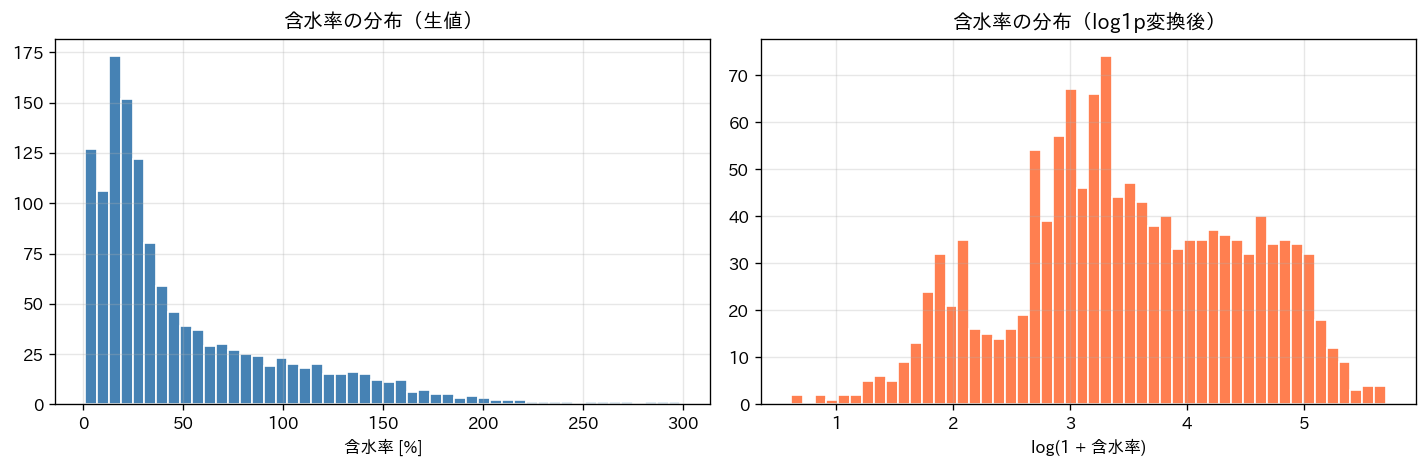

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train['含水率'].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('含水率の分布（生値）')
axes[0].set_xlabel('含水率 [%]')
np.log1p(train['含水率']).hist(bins=50, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('含水率の分布（log1p変換後）')
axes[1].set_xlabel('log(1 + 含水率)')

plt.tight_layout()
plt.show()

## 4. 樹種別の含水率分布（boxplot / agg stats）

C:\Users\enzos\AppData\Local\Temp\ipykernel_23992\748887623.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_species, labels=species_order, patch_artist=True)


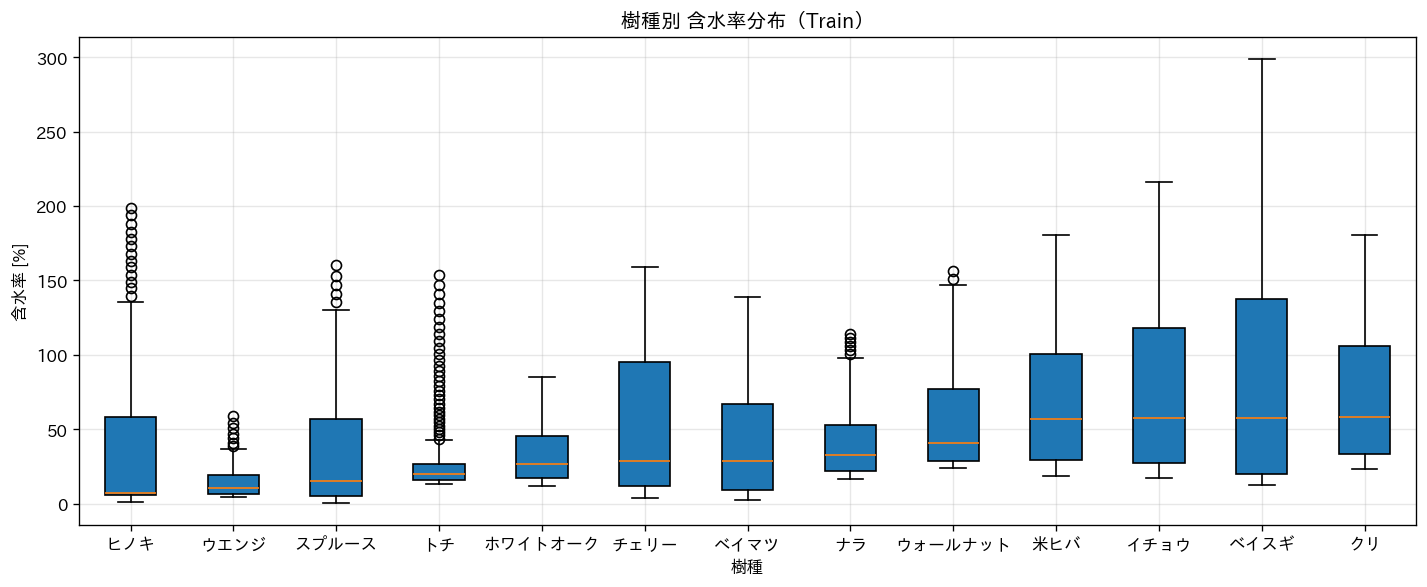

          min    max  median   std
樹種                                
イチョウ     17.2  216.1    57.3  58.4
ウエンジ      4.2   58.7    10.8  12.4
ウォールナット  24.2  156.2    40.6  36.6
クリ       23.2  180.4    58.0  45.8
スプルース     0.8  160.1    15.5  42.8
チェリー      4.1  158.9    28.4  49.7
トチ       13.3  153.8    20.1  29.3
ナラ       16.9  114.1    32.6  25.7
ヒノキ       1.0  198.5     7.3  53.2
ベイスギ     12.8  298.6    57.4  80.4
ベイマツ      2.6  138.9    28.5  38.3
ホワイトオーク  12.2   84.9    26.5  20.2
米ヒバ      18.6  180.5    56.8  46.6


In [9]:
species_order = train.groupby('樹種')['含水率'].median().sort_values().index
data_by_species = [train[train['樹種'] == s]['含水率'].values for s in species_order]

fig, ax = plt.subplots(figsize=(12, 5))
ax.boxplot(data_by_species, labels=species_order, patch_artist=True)
ax.set_xlabel('樹種')
ax.set_ylabel('含水率 [%]')
ax.set_title('樹種別 含水率分布（Train）')
plt.tight_layout()
plt.show()
print(train.groupby('樹種')['含水率'].agg(['min', 'max', 'median', 'std']).round(1))

## 5. NIRスペクトルの可視化（平均+距離 / 全サンプル / 3サンプル+水吸収帯）

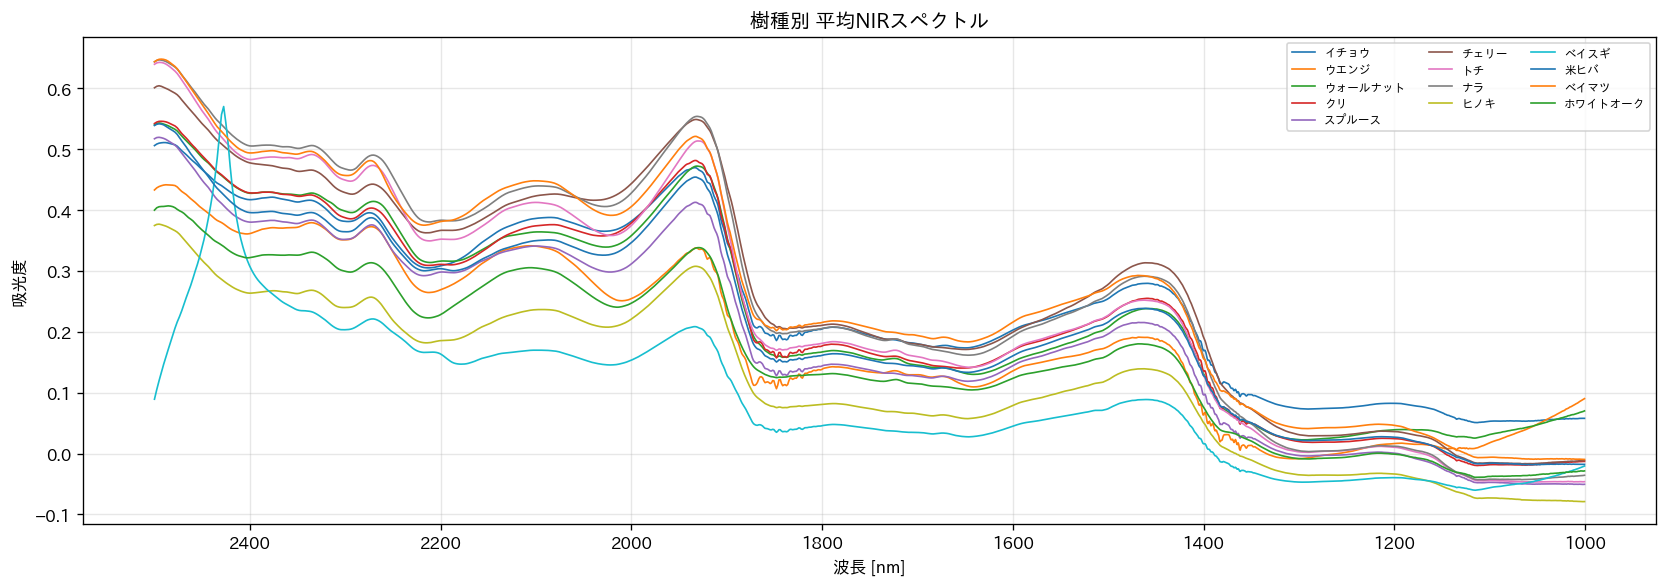

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))

for species in train['樹種'].unique():
    subset = train[train['樹種'] == species]
    ax.plot(WAVELENGTHS, subset[SPEC_COLS].mean().values, linewidth=1, label=species)

ax.set_xlabel('波長 [nm]')
ax.set_ylabel('吸光度')
ax.set_title('樹種別 平均NIRスペクトル')
ax.legend(fontsize=7, ncol=3)
ax.invert_xaxis()
plt.tight_layout()
plt.show()

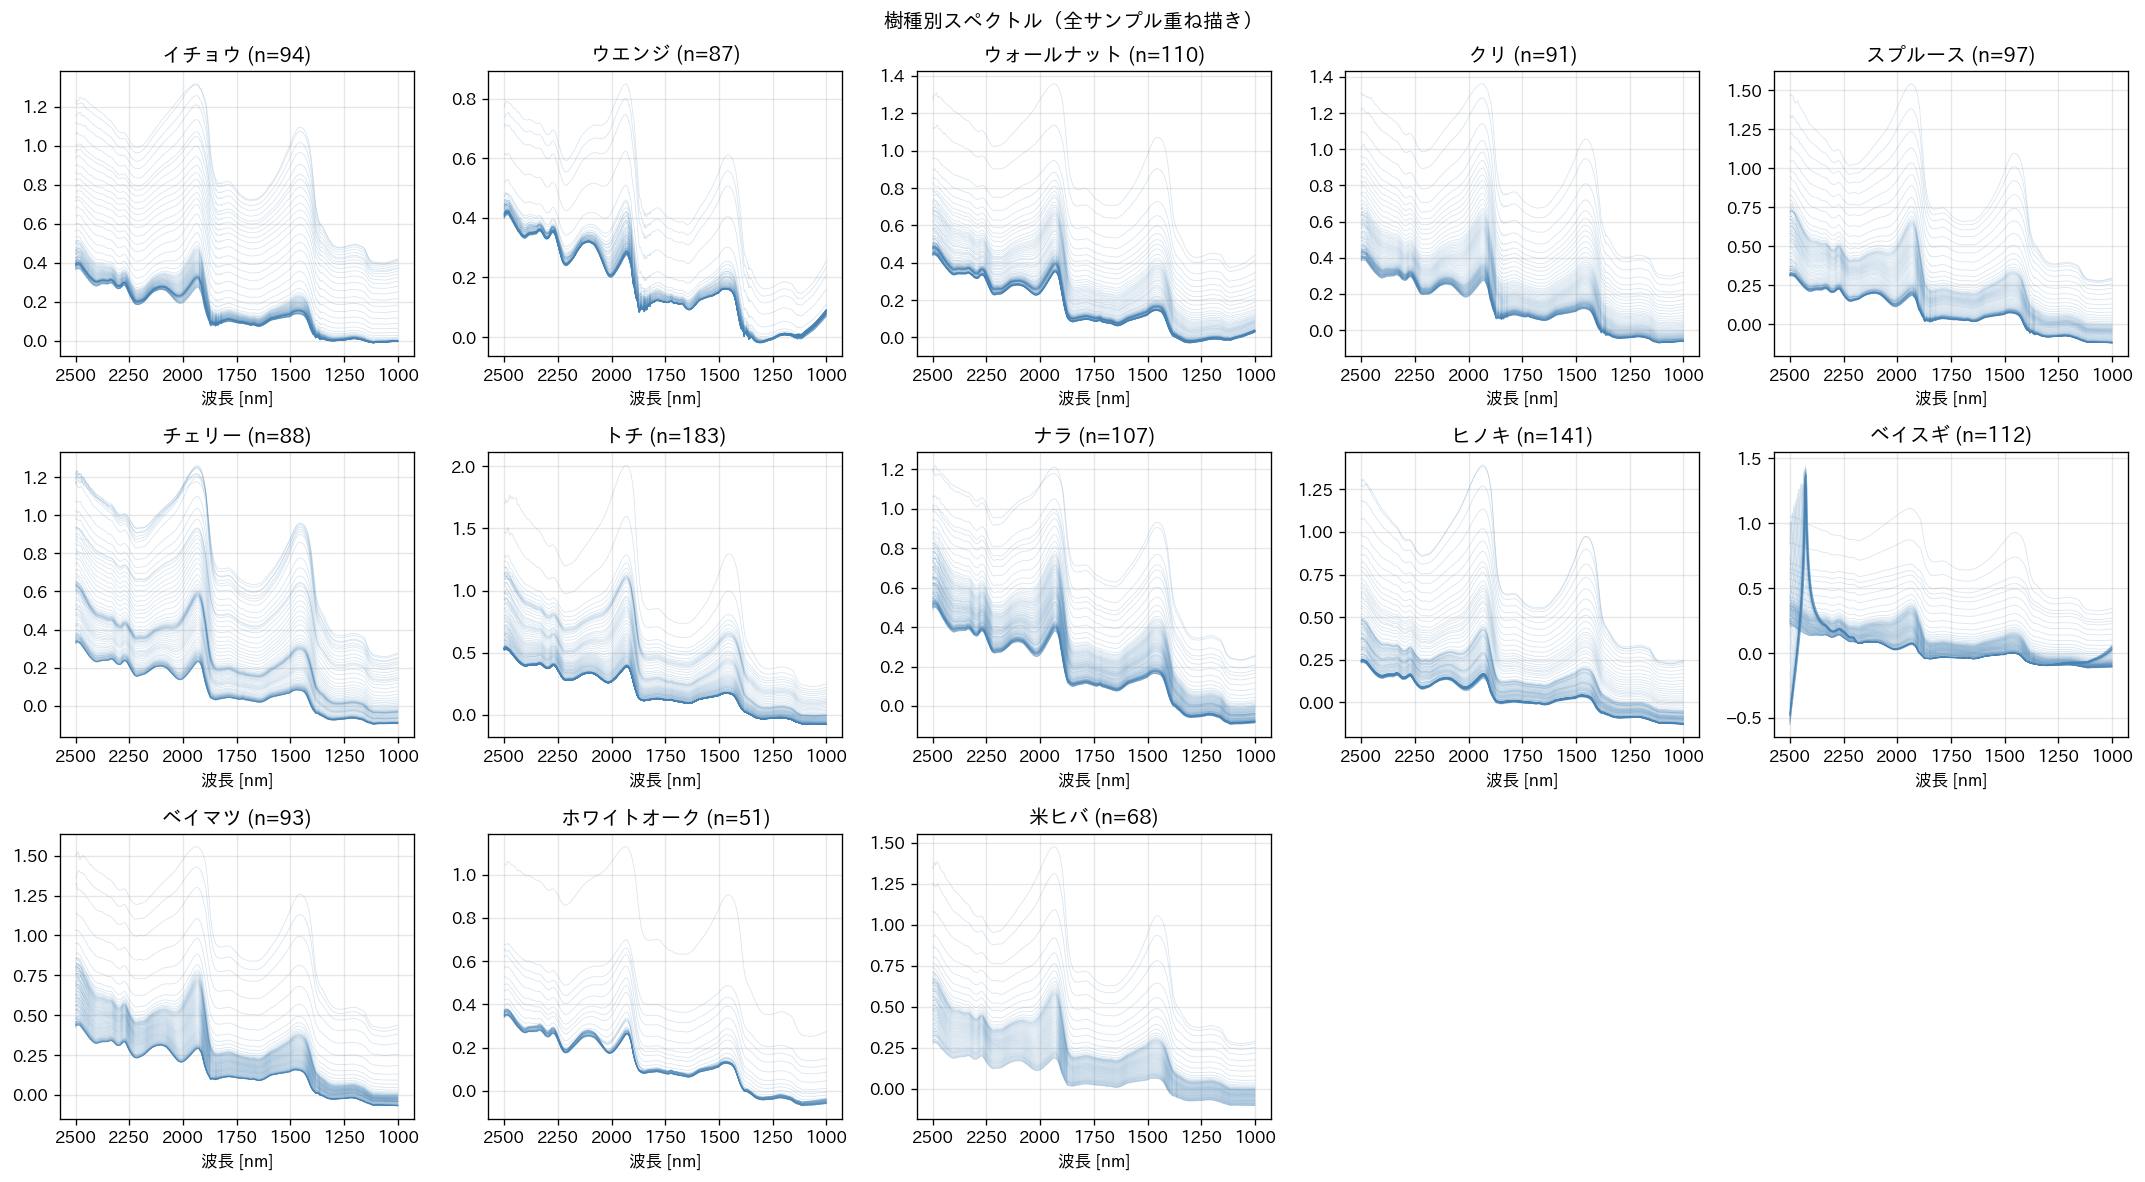

In [11]:
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

for i, species in enumerate(sorted(train['樹種'].unique())):
    subset = train[train['樹種'] == species].sort_values('含水率')
    for _, row in subset.iterrows():
        axes[i].plot(WAVELENGTHS, row[SPEC_COLS].values,
                     alpha=0.2, linewidth=0.5, color='steelblue')
    axes[i].set_title(f'{species} (n={len(subset)})')
    axes[i].invert_xaxis()
    axes[i].set_xlabel('波長 [nm]')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('樹種別スペクトル（全サンプル重ね描き）')
plt.tight_layout()
plt.show()

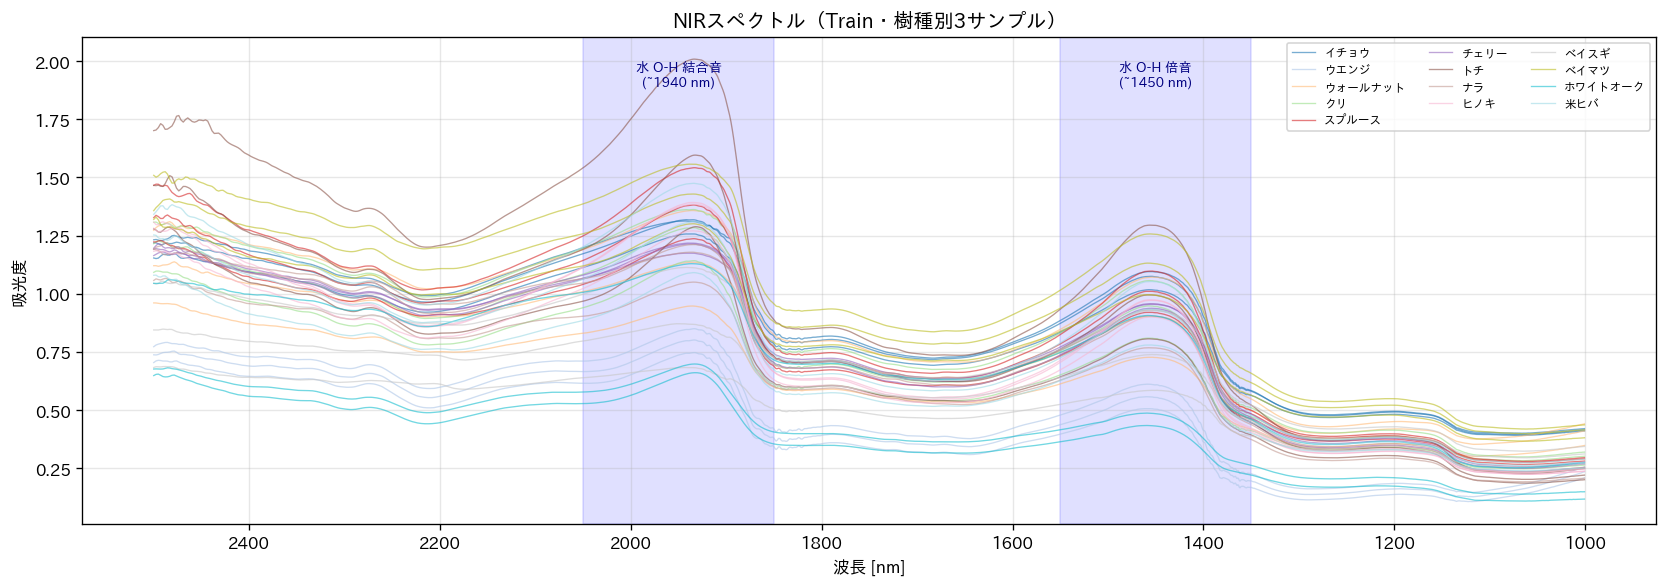

In [12]:
water_bands = [
    (1350, 1550, '水 O-H 倍音\n(~1450 nm)'),
    (1850, 2050, '水 O-H 結合音\n(~1940 nm)'),
]

fig, ax = plt.subplots(figsize=(14, 5))
colors = cm.tab20(np.linspace(0, 1, len(train_species)))

for i, species in enumerate(sorted(train_species)):
    subset = train[train['樹種'] == species].head(3)
    for j, (_, row) in enumerate(subset.iterrows()):
        label = species if j == 0 else None
        ax.plot(WAVELENGTHS, row[SPEC_COLS].values,
                color=colors[i], alpha=0.6, linewidth=0.8, label=label)

for wl_min, wl_max, label in water_bands:
    ax.axvspan(wl_min, wl_max, alpha=0.12, color='blue')
    ax.text((wl_min + wl_max)/2, ax.get_ylim()[1]*0.9, label,
            ha='center', fontsize=8, color='navy')

ax.set_xlabel('波長 [nm]')
ax.set_ylabel('吸光度')
ax.set_title('NIRスペクトル（Train・樹種別3サンプル）')
ax.legend(loc='upper right', fontsize=7, ncol=3)
ax.invert_xaxis()
plt.tight_layout()
plt.show()

## 6. 含水率とスペクトルの関係

C:\Users\enzos\AppData\Local\Temp\ipykernel_23992\3897845322.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['mc_group'] = pd.qcut(train['含水率'], q=5,


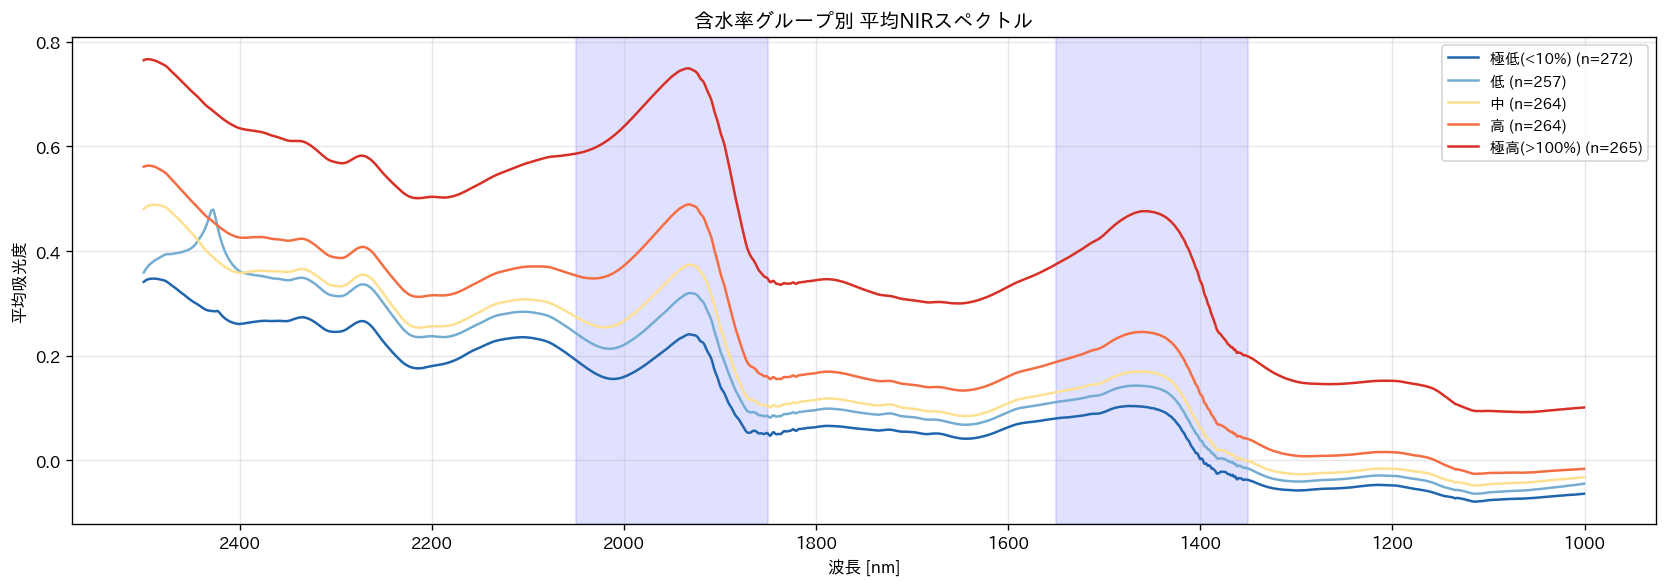

In [13]:
train['mc_group'] = pd.qcut(train['含水率'], q=5,
                             labels=['極低(<10%)', '低', '中', '高', '極高(>100%)'])

fig, ax = plt.subplots(figsize=(14, 5))
colors_mc = ['#2166ac', '#74add1', '#fee090', '#f46d43', '#d73027']

for grp, color in zip(['極低(<10%)', '低', '中', '高', '極高(>100%)'], colors_mc):
    subset = train[train['mc_group'] == grp]
    mean_spec = subset[SPEC_COLS].mean().values
    ax.plot(WAVELENGTHS, mean_spec, color=color, linewidth=1.5,
            label=f'{grp} (n={len(subset)})')

for wl_min, wl_max, label in water_bands:
    ax.axvspan(wl_min, wl_max, alpha=0.12, color='blue')

ax.set_xlabel('波長 [nm]')
ax.set_ylabel('平均吸光度')
ax.set_title('含水率グループ別 平均NIRスペクトル')
ax.legend(fontsize=9)
ax.invert_xaxis()
plt.tight_layout()
plt.show()

## 7. 各波長と含水率の相関係数（相関プロット / top/bottom / ヒートマップ）

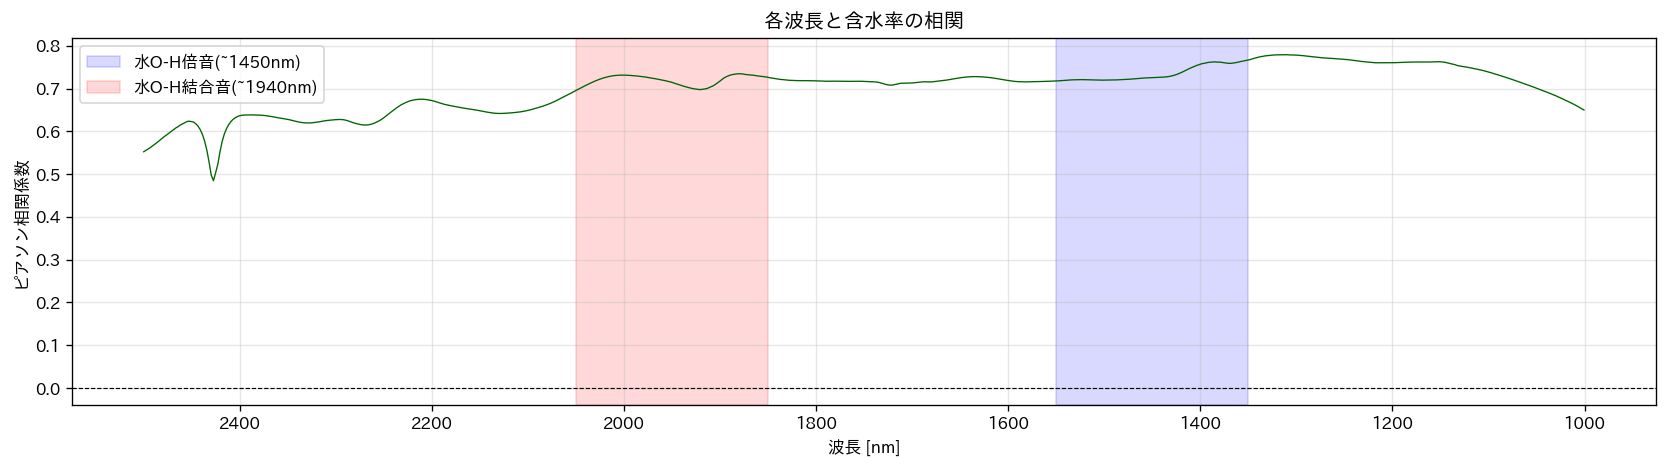

相関が最も高い（正）上位5波長:
7617.78905    0.7791
7621.64616    0.7791
7613.93194    0.7791
7625.50326    0.7790
7610.07483    0.7790
dtype: float64

相関が最も低い（負）上位5波長:
4119.39175    0.4846
4115.53464    0.4976
4123.24886    0.5029
4127.10596    0.5227
4111.67753    0.5284
dtype: float64


In [14]:
correlations = train[SPEC_COLS].corrwith(train['含水率'])

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(WAVELENGTHS, correlations.values, linewidth=0.8, color='darkgreen')
ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
ax.axvspan(1350, 1550, alpha=0.15, color='blue', label='水O-H倍音(~1450nm)')
ax.axvspan(1850, 2050, alpha=0.15, color='red', label='水O-H結合音(~1940nm)')
ax.set_xlabel('波長 [nm]')
ax.set_ylabel('ピアソン相関係数')
ax.set_title('各波長と含水率の相関')
ax.legend()
ax.invert_xaxis()
plt.tight_layout()
plt.show()
print('相関が最も高い（正）上位5波長:')
print(correlations.nlargest(5).round(4))

print('\n相関が最も低い（負）上位5波長:')
print(correlations.nsmallest(5).round(4))


## 8. PCA（Train / Train+Test）

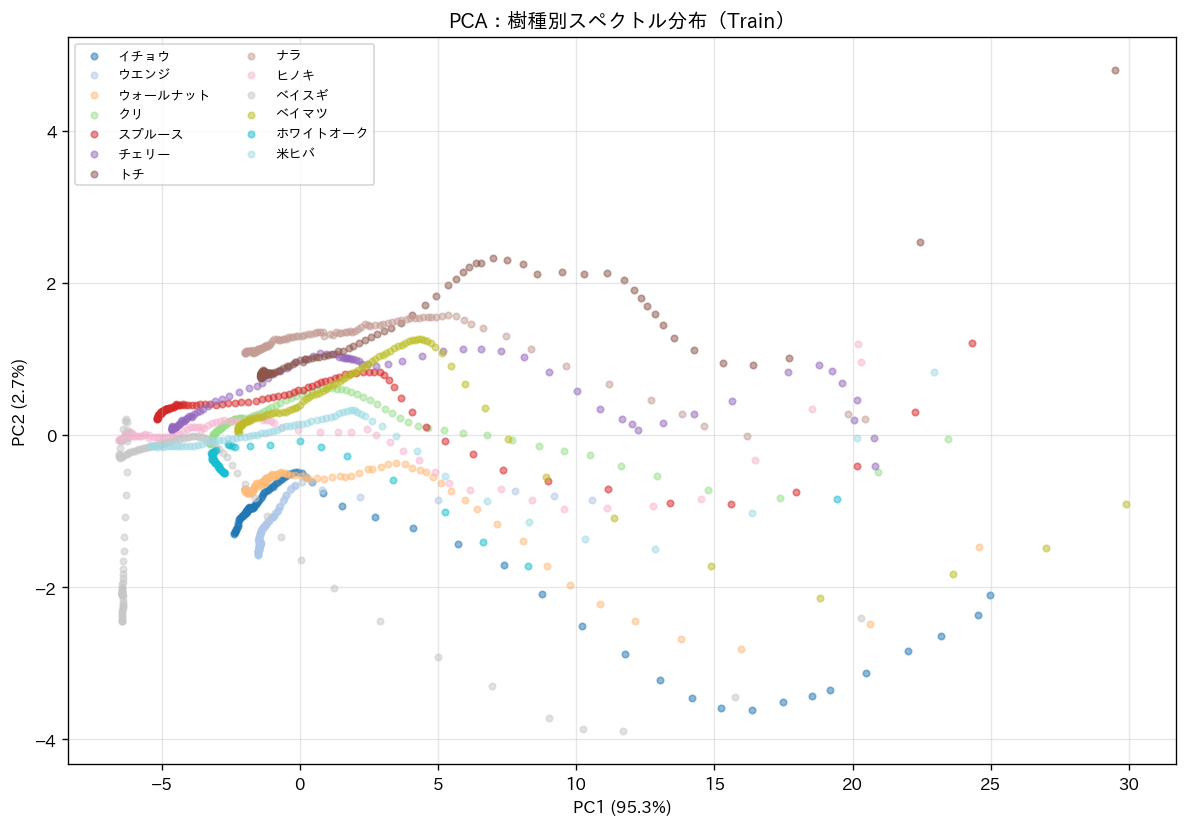

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = train[SPEC_COLS].values
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(10, 7))
species_list = train['樹種'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(species_list)))

for species, color in zip(sorted(species_list), colors):
    mask = train['樹種'] == species
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               label=species, alpha=0.5, s=15, color=color)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA：樹種別スペクトル分布（Train）')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

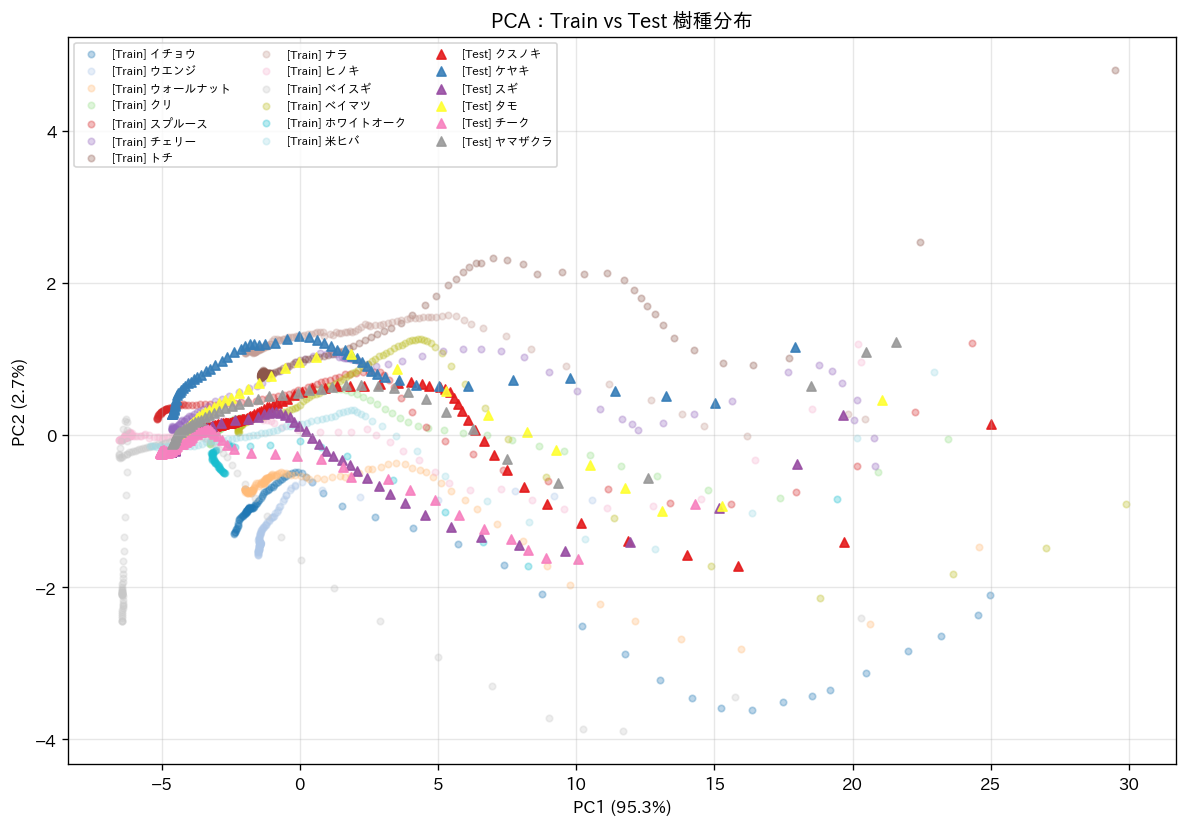

In [16]:
X_test_pca = pca.transform(test[SPEC_COLS].values)

fig, ax = plt.subplots(figsize=(10, 7))

# Train樹種（薄め）
for species, color in zip(sorted(species_list), colors):
    mask = train['樹種'] == species
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               label=f'[Train] {species}', alpha=0.3, s=15, color=color)

# Test樹種（濃く・マーカー変更）
test_species_list = test['樹種'].unique()
test_colors = plt.cm.Set1(np.linspace(0, 1, len(test_species_list)))

for species, color in zip(sorted(test_species_list), test_colors):
    mask = test['樹種'] == species
    ax.scatter(X_test_pca[mask, 0], X_test_pca[mask, 1],
               label=f'[Test] {species}', alpha=0.9, s=30,
               color=color, marker='^')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA：Train vs Test 樹種分布')
ax.legend(fontsize=7, ncol=3)
plt.tight_layout()
plt.show()


## 9. 外れ値スペクトルの確認

In [21]:
threshold = train['含水率'].quantile(0.99)
outliers = train[train['含水率'] > threshold]
print(f'99パーセンタイル: {threshold:.1f}%')
print(outliers[['樹種', '含水率']])

99パーセンタイル: 211.8%
        樹種         含水率
0     イチョウ  216.129032
998   ベイスギ  298.581560
999   ベイスギ  288.652482
1000  ベイスギ  280.851064
1001  ベイスギ  273.049645
1002  ベイスギ  265.957447
1003  ベイスギ  258.865248
1004  ベイスギ  251.063830
1005  ベイスギ  244.680851
1006  ベイスギ  237.588652
1007  ベイスギ  231.205674
1008  ベイスギ  224.822695
1009  ベイスギ  217.730496
1010  ベイスギ  212.056738


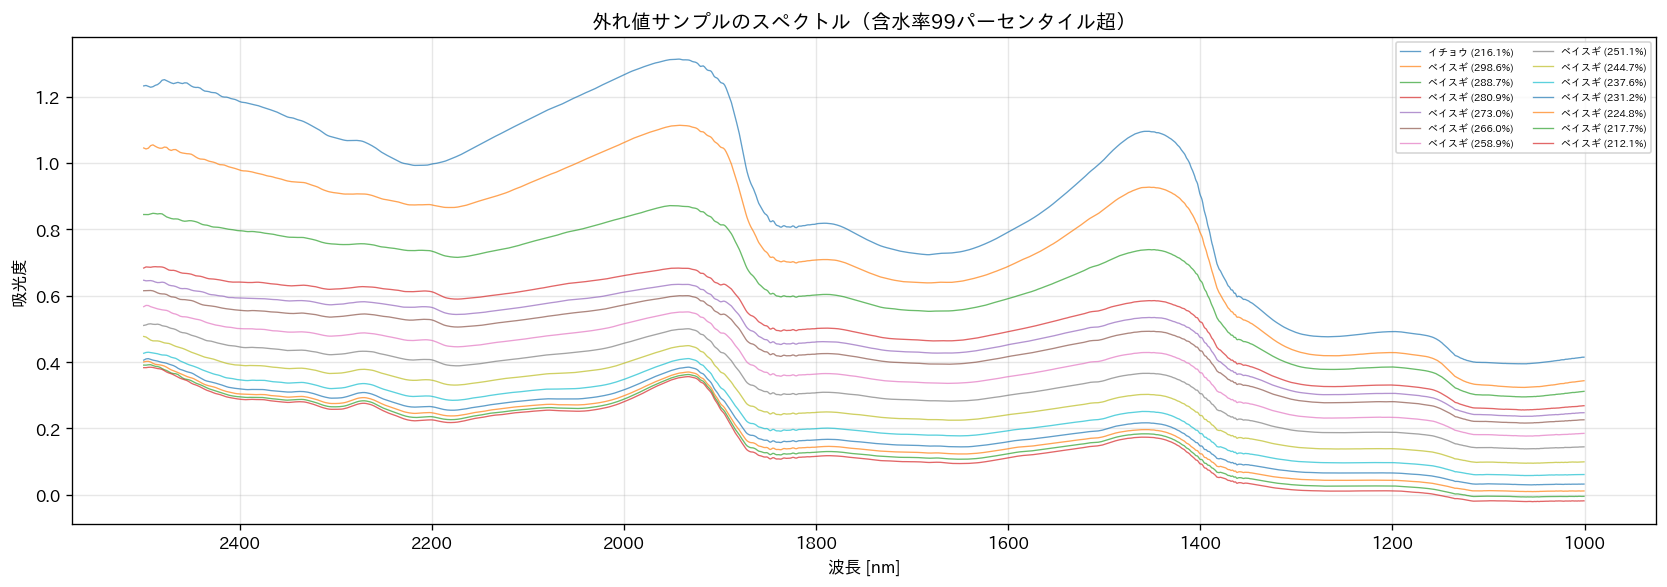

In [22]:
fig, ax = plt.subplots(figsize=(14, 5))

for _, row in outliers.iterrows():
    ax.plot(WAVELENGTHS, row[SPEC_COLS].values,
            alpha=0.7, linewidth=0.8,
            label=f'{row["樹種"]} ({row["含水率"]:.1f}%)')

ax.set_xlabel('波長 [nm]')
ax.set_ylabel('吸光度')
ax.set_title('外れ値サンプルのスペクトル（含水率99パーセンタイル超）')
ax.invert_xaxis()
ax.legend(fontsize=6, ncol=2)
plt.tight_layout()
plt.show()

## 9b. スペクトル統計量の詳細分析

C:\Users\enzos\AppData\Local\Temp\ipykernel_23992\1808902537.py:32: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) IPAexGothic.
  plt.tight_layout()
C:\Users\enzos\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) IPAexGothic.
  fig.canvas.print_figure(bytes_io, **kw)


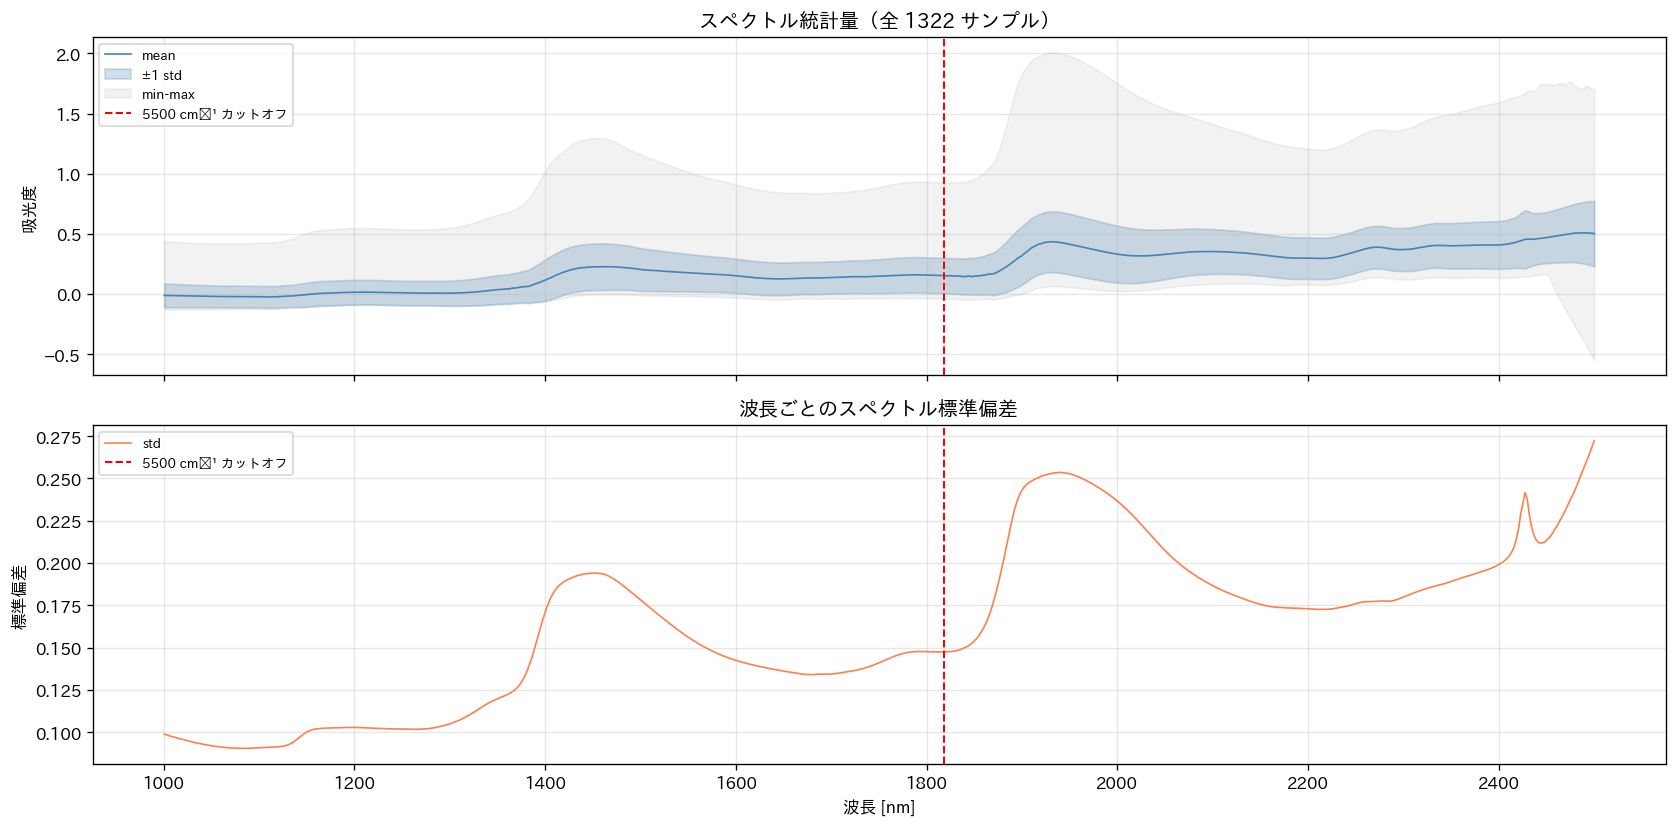

In [17]:
# --- 1. 波長ごとの統計量（mean / std / min / max）---
X = train[SPEC_COLS].values
spec_mean = X.mean(axis=0)
spec_std  = X.std(axis=0)
spec_min  = X.min(axis=0)
spec_max  = X.max(axis=0)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(WAVELENGTHS, spec_mean, color='steelblue', lw=1, label='mean')
axes[0].fill_between(WAVELENGTHS,
                     spec_mean - spec_std,
                     spec_mean + spec_std,
                     alpha=0.25, color='steelblue', label='±1 std')
axes[0].fill_between(WAVELENGTHS, spec_min, spec_max,
                     alpha=0.10, color='gray', label='min-max')
axes[0].set_ylabel('吸光度')
axes[0].set_title('スペクトル統計量（全 1322 サンプル）')
axes[0].legend(fontsize=8)

axes[1].plot(WAVELENGTHS, spec_std, color='coral', lw=1, label='std')
axes[1].set_ylabel('標準偏差')
axes[1].set_xlabel('波長 [nm]')
axes[1].set_title('波長ごとのスペクトル標準偏差')

# 5500 cm⁻¹ = 1818 nm に垂直線（現モデルのカットオフ）
for ax in axes:
    ax.axvline(1818, color='red', lw=1.2, ls='--', label='5500 cm⁻¹ カットオフ')
    ax.invert_xaxis()
axes[0].legend(fontsize=8)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

C:\Users\enzos\AppData\Local\Temp\ipykernel_23992\4110270790.py:32: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) IPAexGothic.
  plt.tight_layout()


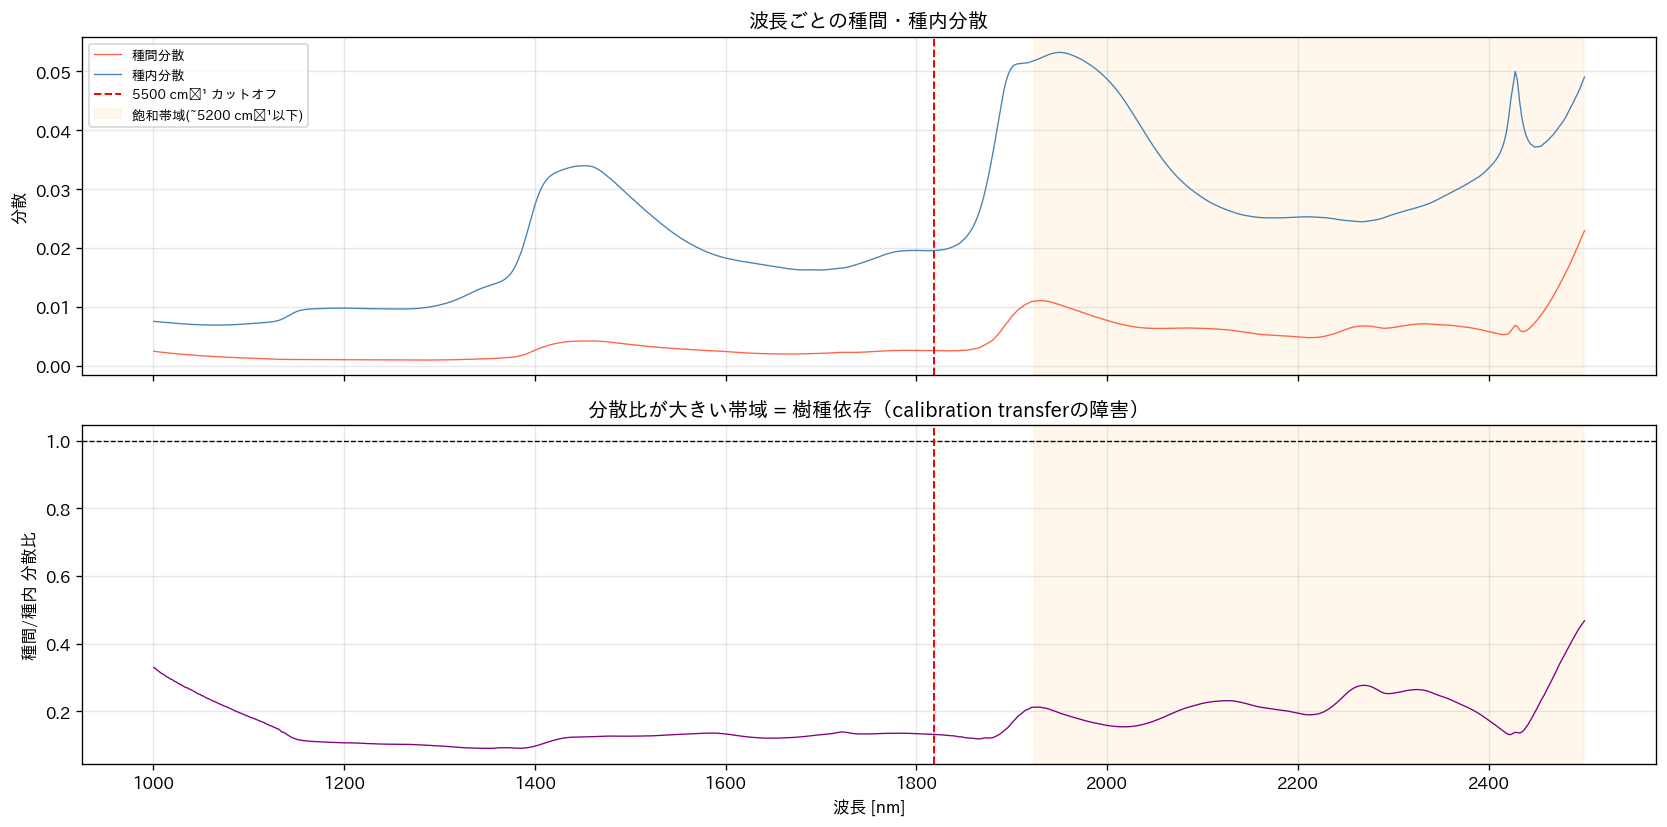

In [18]:
# --- 2. 種間分散 vs 種内分散（波長ごと）---
# 種間分散が大きい = 樹種固有のシグナル（moisture信号の邪魔）
# 種内分散が大きい = 含水率変動のシグナル（有用）

between_var = np.array([
    train.groupby('樹種')[c].mean().var() for c in SPEC_COLS
])
within_var = np.array([
    train.groupby('樹種')[c].var().mean() for c in SPEC_COLS
])
ratio = between_var / (within_var + 1e-10)  # 種間/種内 比

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(WAVELENGTHS, between_var, color='tomato',  lw=0.8, label='種間分散')
axes[0].plot(WAVELENGTHS, within_var,  color='steelblue', lw=0.8, label='種内分散')
axes[0].set_ylabel('分散')
axes[0].set_title('波長ごとの種間・種内分散')
axes[0].legend(fontsize=8)

axes[1].plot(WAVELENGTHS, ratio, color='purple', lw=0.8)
axes[1].axhline(1, color='black', ls='--', lw=0.8)
axes[1].set_ylabel('種間/種内 分散比')
axes[1].set_xlabel('波長 [nm]')
axes[1].set_title('分散比が大きい帯域 = 樹種依存（calibration transferの障害）')

for ax in axes:
    ax.axvline(1818, color='red', lw=1.2, ls='--', label='5500 cm⁻¹ カットオフ')
    ax.axvspan(1923, 2500, alpha=0.08, color='orange', label='飽和帯域(~5200 cm⁻¹以下)')
    ax.invert_xaxis()
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

C:\Users\enzos\AppData\Local\Temp\ipykernel_23992\3840482938.py:43: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) IPAexGothic.
  plt.tight_layout()


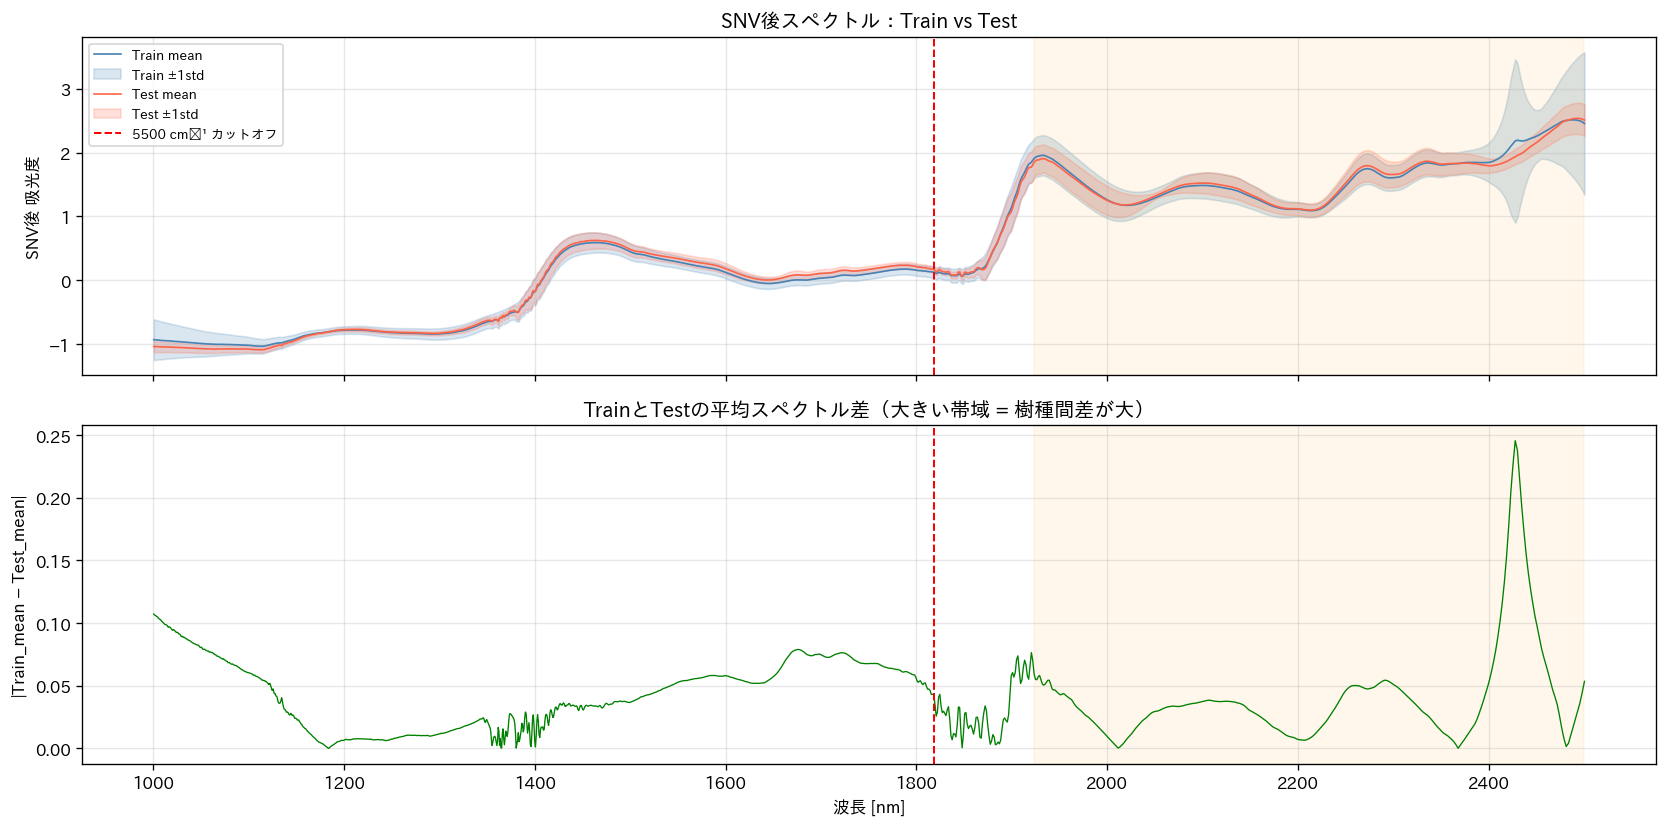

In [19]:
# --- 3. SNV後スペクトルの統計量 + Train vs Test 比較 ---
from scipy.signal import savgol_filter

def snv(X):
    return (X - X.mean(axis=1, keepdims=True)) / X.std(axis=1, keepdims=True)

X_tr  = train[SPEC_COLS].values
X_te  = test[SPEC_COLS].values
X_tr_snv = snv(X_tr)
X_te_snv = snv(X_te)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Train
tr_mean = X_tr_snv.mean(axis=0)
tr_std  = X_tr_snv.std(axis=0)
axes[0].plot(WAVELENGTHS, tr_mean, color='steelblue', lw=1, label='Train mean')
axes[0].fill_between(WAVELENGTHS, tr_mean - tr_std, tr_mean + tr_std,
                     alpha=0.2, color='steelblue', label='Train ±1std')

# Test
te_mean = X_te_snv.mean(axis=0)
te_std  = X_te_snv.std(axis=0)
axes[0].plot(WAVELENGTHS, te_mean, color='tomato', lw=1, label='Test mean')
axes[0].fill_between(WAVELENGTHS, te_mean - te_std, te_mean + te_std,
                     alpha=0.2, color='tomato', label='Test ±1std')

axes[0].set_ylabel('SNV後 吸光度')
axes[0].set_title('SNV後スペクトル：Train vs Test')
axes[0].legend(fontsize=8)

# 差分（Testがどれだけ離れているか）
axes[1].plot(WAVELENGTHS, np.abs(tr_mean - te_mean), color='green', lw=0.8)
axes[1].set_ylabel('|Train_mean − Test_mean|')
axes[1].set_xlabel('波長 [nm]')
axes[1].set_title('TrainとTestの平均スペクトル差（大きい帯域 = 樹種間差が大）')

for ax in axes:
    ax.axvline(1818, color='red', lw=1.2, ls='--', label='5500 cm⁻¹ カットオフ')
    ax.axvspan(1923, 2500, alpha=0.08, color='orange')
    ax.invert_xaxis()
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

C:\Users\enzos\AppData\Local\Temp\ipykernel_23992\547721416.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['mc_bin'] = pd.cut(train['含水率'], bins=bins, labels=labels)
C:\Users\enzos\AppData\Local\Temp\ipykernel_23992\547721416.py:26: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) IPAexGothic.
  plt.tight_layout()


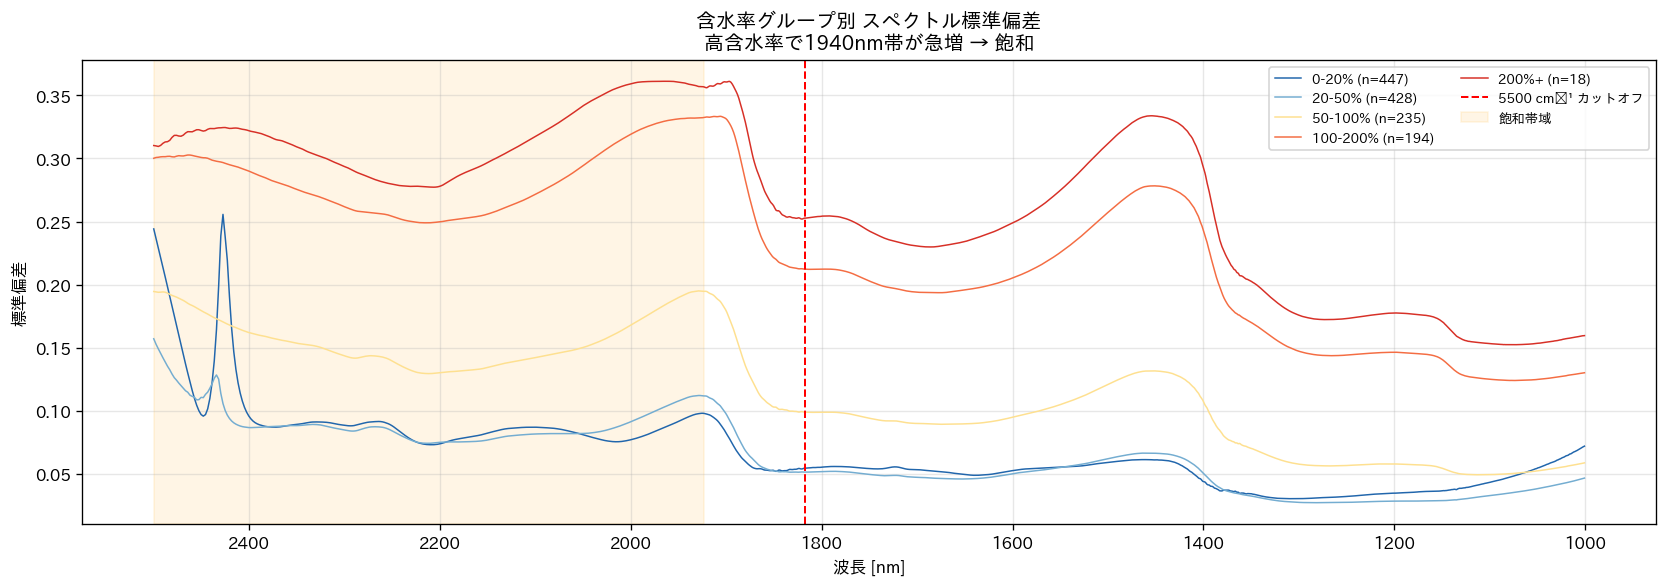

含水率グループ別の代表帯域での標準偏差:
グループ        5500+帯域mean_std  5500以下帯域mean_std
  0-20%       0.0464              0.0888
  20-50%      0.0407              0.0866
  50-100%     0.0753              0.1517
  100-200%    0.1736              0.2812
  200%+       0.2097              0.3159


In [20]:
# --- 4. 含水率グループ別の標準偏差（飽和の可視化）---
# 高含水率サンプルで特定波長のstdが急増 → 飽和の証拠

bins   = [0, 20, 50, 100, 200, 999]
labels = ['0-20%', '20-50%', '50-100%', '100-200%', '200%+']
train['mc_bin'] = pd.cut(train['含水率'], bins=bins, labels=labels)

fig, ax = plt.subplots(figsize=(14, 5))
colors_bin = ['#2166ac', '#74add1', '#fee090', '#f46d43', '#d73027']

for label, color in zip(labels, colors_bin):
    subset = train[train['mc_bin'] == label]
    if len(subset) == 0:
        continue
    std_spec = subset[SPEC_COLS].values.std(axis=0)
    ax.plot(WAVELENGTHS, std_spec, color=color, lw=0.9,
            label=f'{label} (n={len(subset)})')

ax.axvline(1818, color='red', lw=1.2, ls='--', label='5500 cm⁻¹ カットオフ')
ax.axvspan(1923, 2500, alpha=0.10, color='orange', label='飽和帯域')
ax.set_xlabel('波長 [nm]')
ax.set_ylabel('標準偏差')
ax.set_title('含水率グループ別 スペクトル標準偏差\n高含水率で1940nm帯が急増 → 飽和')
ax.legend(fontsize=8, ncol=2)
ax.invert_xaxis()
plt.tight_layout()
plt.show()

# 帯域別の数値サマリ
print('含水率グループ別の代表帯域での標準偏差:')
print(f"{'グループ':10s}  5500+帯域mean_std  5500以下帯域mean_std")
for label in labels:
    subset = train[train['mc_bin'] == label]
    if len(subset) == 0:
        continue
    X_sub = subset[SPEC_COLS].values
    std_above = X_sub[:, WAVENUMS >= 5500].std(axis=0).mean()
    std_below = X_sub[:, WAVENUMS <  5500].std(axis=0).mean()
    print(f"  {label:10s}  {std_above:.4f}              {std_below:.4f}")

## 10. まとめ

| 項目 | 内容 |
|------|------|
| **データ規模** | Train: 1322件×1559列 / Test: 550件×1558列 / 欠損値なし |
| **Train/Test の樹種** | 完全に別種（重複ゼロ）→ calibration transfer 問題 |
| **含水率の分布** | 右裾が長い（0.84〜298%）/ log1p変換はモデル上悪化するため使わない |
| **樹種別含水率** | ベイスギ（std=80）・ヒノキ（std=53）が特に広範囲、ウエンジ（std=12）は狭い |
| **水の吸収帯** | 1450 nm・1940 nm 付近が含水率と高い相関（r≈0.78） |
| **波長間相関** | ほぼ全波長が高相関 → 独立情報は数十次元程度 |
| **PCA** | PC1（95%超）が含水率軸 / 各樹種が独自の軌跡を描く → 種間で関数が異なる証拠 |
| **Train vs Test PCA** | TestはTrainの空間内に混在 → 完全転移不可だが部分転移は可能 |
| **外れ値** | 99パーセンタイル超はベイスギ13件+イチョウ1件 / スペクトルは正常、除外不要 |

### 次のステップ
- `02_preprocessing.ipynb`: SNV・Savitzky-Golay微分などの前処理を実装・比較
- `03_baseline_pls.ipynb`: PLS回帰＋GroupKFold CVでベースラインスコアを確立